# The Colorado River Storage Project (CRSP)

<figure style="float:right; width:300px; margin-left:15px;">
  <img src="images/Colorado_River_Storage_Project_map.png"
       alt="Map of Colorado River Storage Project units">
  <figcaption style="font-size:0.8em; color:#666;">
    Map of CRSP units. Shannon1, own work,
    <a href="https://commons.wikimedia.org/w/index.php?curid=58520344">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

This companion notebook to the Grand Canyon streamflow work displays how much water is
banked in the upstream Colorado River Storage Project reservoirs.

The Colorado River Storage Project (CRSP) is a massive, multi-state federal water management
initiative authorized by the U.S. Congress in 1956. Managed by the Bureau of Reclamation, its
primary goal is to regulate the flow of the Upper Colorado River Basin, ensure equitable water
distribution, and provide long-term water storage for the American West.

The project is anchored by four primary storage units:

- **Glen Canyon Unit** &mdash; anchored by Glen Canyon Dam, creating Lake Powell (Utah/Arizona),
    the largest storage component of the project.
- **Flaming Gorge Unit** &mdash; anchored by Flaming Gorge Dam on the Green River (Utah/Wyoming).
- **Navajo Unit** &mdash; anchored by Navajo Dam on the San Juan River (New Mexico/Colorado).
- **Wayne N. Aspinall Unit** &mdash; a series of three dams (**Blue Mesa**, **Morrow Point**, and
    **Crystal**) along the Gunnison River in Colorado.

Fontenelle (Green River, Wyoming) is a CRSP participating-project reservoir upstream of Flaming
Gorge, included here as well.

> **Upstream vs. downstream.** Every reservoir in this notebook is a CRSP *Upper Basin* unit
> &mdash; the "bank account" of stored water. Lake Mead (Hoover Dam) is **not** CRSP; it predates
> the project and serves the Lower Basin, so it is deliberately excluded here.

## The Reclamation Information Sharing Environment (RISE)

RISE is the U.S. Bureau of Reclamation's centralized open-data platform. This notebook pulls
multi-year daily storage from the RISE API (`data.usbr.gov/rise/api`), which reaches back far
enough to show the drought decline rather than just the most recent year.

Useful entry points:

- Map interface: https://data.usbr.gov/rise-map/
- Time-series query (find item IDs): https://data.usbr.gov/time-series/search?v=1
- Catalog of locations: https://data.usbr.gov/rise/api/catalog/items?type=location
- Catalog of parameters: https://data.usbr.gov/rise/api/catalog/items?type=parameter
- Reclamation reservoir dashboard:
    https://usbr.maps.arcgis.com/apps/dashboards/81aaec3e74024ce6b9a5e50caa20984e

## Three nested ID systems

RISE identifies things at three levels, and it helps to keep them straight:

- **Location ID** &mdash; the physical place (a dam/reservoir). One per reservoir. *Coarsest.*
- **Catalog record** &mdash; a dataset *grouping* about a location. Usually one water-operations
    record per reservoir, but a location can have several (e.g. a separate sedimentation-survey
    record).
- **Item ID** &mdash; a single time series: one parameter, one timestep, one unit (e.g. *Storage*
    in acre-feet). A catalog record holds many items. *Finest &mdash; this is what the code fetches.*

Hierarchy: **location (1536) ⊃ catalog record (2305) ⊃ item (347 = storage)**.

Two practical consequences:

1. The **item ID is the only number the code needs**. Location and catalog IDs are navigational
   breadcrumbs you use once, by hand, to *find* the item.
2. **Item IDs are not aligned across reservoirs** (Powell storage = 509, Flaming Gorge = 337,
   Fontenelle = 347). They were assigned as series were registered, so each must be looked up
   individually rather than computed. Storage and elevation are sometimes adjacent within one
   reservoir (Navajo: 612 elev / 613 storage) but **do not rely on it** &mdash; Fontenelle breaks
   the pattern (347 storage, 349 elevation).


## Reservoirs and their RISE IDs 

**Storage item IDs &mdash; all primary CRSP units**

| Reservoir | Location ID | Catalog | Storage item ID | Live capacity (af) | River (States) |
|---|---|---|---|---|---|
| Lake Powell   | 393  | 2362 | **509** | 23,314,000 | Colorado River (UT/AZ) |
| Flaming Gorge | 1535 | 2300 | **337** |  3,749,000 | Green River (UT/WY) |
| Navajo        | 423  | 2392 | **613** |  1,696,000 | San Juan River (NM/CO) |
| Blue Mesa     | 1533 | 2249 | **76**  |    827,472 | Gunnison River (CO) |
| Fontenelle    | 1536 | 2305 | **347** |    344,800 | Green River (WY) |
| Morrow Point  | 417  | 2386 | **592** |    117,190 | Gunnison River (CO) |
| Crystal       | 1534 | 2278 | **274** |     25,236 | Gunnison River (CO) |


**Gotchas learned:**
- Each reservoir exposes both elevation AND storage; grab the **Storage-af** item, not
  Elevation-ft. (Adjacent numbering is common but not guaranteed &mdash; see Fontenelle.)
- Powell has several map stations (3269 power plant, 3542 Halls Crossing, 3539 Bullfrog Marina).
  Only location **393** (Glen Canyon Dam & Power Plant) is the official reservoir storage. The
  map pin sits slightly up-lake of the dam &mdash; that's the forebay gauge, expected.
- **Value check is ground truth:** storage ≈ hundreds-of-thousands to millions of acre-feet; if a
  series returns ~thousands it's elevation (feet) &mdash; wrong item.
- **Morrow Point and Crystal are re-regulation pools**, not storage reservoirs. They run nearly
  full year-round (peaking / run-of-river below Blue Mesa) and do *not* track drought the way
  Powell and Blue Mesa do. Their percent-full will sit near 100% regardless of basin conditions.


# Parameter codes (RISE `parameterId`)

These are the *parameter* codes (distinct from item IDs). Handy when browsing the catalog or
filtering the parameter table built near the end of this notebook.

| Code | Parameter | Unit |
|---|---|---|
| 16 | Reservoir Storage / Capacity | acre-feet |
| 17 | Reservoir Water-Surface Elevation | feet |
| 22 | Total Hydropower Generation | MW |
| 28 | Total River Release / Tailwater Discharge | cfs |
| 29 | Reservoir Inflow | cfs |
| 49 | Turbine / Power-Plant Discharge | cfs |
| 50 | Spillway Discharge | cfs |

Note: the **item ID** (what `rise_series` fetches) is reservoir-specific; the **parameter code**
above is shared across all reservoirs. A storage time series is parameter 16 at every reservoir,
but its item ID differs per reservoir.


In [17]:
import datetime as dt
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests

## Fetch and parse RISE time series

In [18]:
TZ = "America/Phoenix"
START_DATE = "20000101"
END_DATE = (dt.date.today() - dt.timedelta(days=1)).strftime("%Y%m%d")
#END_DATE = "20260621"

RISE_RESULT = "https://data.usbr.gov/rise/api/result"
RISE_HEADERS = {"Accept": "application/vnd.api+json"}


def rise_series(item_id, start=START_DATE, end=END_DATE,
                tz=TZ, items_per_page=2000, max_pages=20):
    """Fetch a RISE catalog item as a tz-aware daily Series (value vs date).

    RISE returns dateTime as aware UTC, so we tz_convert (not tz_localize).
    Dates are YYYYMMDD strings; results are paginated with &page=N.
    """
    records = []
    for page in range(1, max_pages + 1):
        params = {
            "itemId": item_id,
            "order[dateTime]": "ASC",
            "dateTime[after]": start,
            "dateTime[strictly_before]": end,
            "itemsPerPage": items_per_page,
            "page": page,
        }
        r = requests.get(RISE_RESULT, params=params, headers=RISE_HEADERS, timeout=120)
        r.raise_for_status()
        data = r.json().get("data", [])
        if not data:
            break
        records.extend(data)
        if len(data) < items_per_page:
            break

    if not records:
        return pd.Series(dtype=float)

    attrs = [rec["attributes"] for rec in records]
    df = pd.DataFrame(attrs)
    idx = pd.to_datetime(df["dateTime"], utc=True).dt.tz_convert(tz)
    return pd.Series(
        pd.to_numeric(df["result"], errors="coerce").values,
        index=idx, name=f"item_{item_id}",
    ).sort_index()


## Storage item-ID map

All seven primary CRSP units are filled in and confirmed. The build cell below skips any `None`
entry, so the notebook still runs end-to-end if you comment one out or add a new TBD.

In [19]:
STORAGE_ITEM = {
    "Lake Powell":   509,   
    "Flaming Gorge": 337,   
    "Navajo":        613,   
    "Blue Mesa":      76,   
    "Fontenelle":    347,   
    "Morrow Point":  592,   
    "Crystal":       274,   
}

LIVE_CAPACITY_AF = {       
    "Lake Powell":   23_314_000,
    "Flaming Gorge":  3_749_000,
    "Navajo":         1_696_000,
    "Blue Mesa":        827_472,
    "Fontenelle":       344_800,
    "Morrow Point":     117_190,  
    "Crystal":           25_236,   
}

## Build the multi-year storage frame

In [23]:
# Pulls every reservoir that has an item ID filled in (skips None).
storage = pd.DataFrame({
    name: rise_series(item_id)
    for name, item_id in STORAGE_ITEM.items()
    if item_id is not None
}).dropna(how="all")

print(storage.tail())


                           Lake Powell  Flaming Gorge   Navajo  Blue Mesa  \
dateTime                                                                    
2026-06-15 00:00:00-07:00      5695740        2786630  1002310     321122   
2026-06-16 00:00:00-07:00      5695150        2784000  1000400     319329   
2026-06-17 00:00:00-07:00      5693400        2781040   998696     317822   
2026-06-18 00:00:00-07:00      5689890        2779390   996993     315873   
2026-06-19 00:00:00-07:00      5685220        2776110   995393     313932   

                           Fontenelle  Morrow Point  Crystal  
dateTime                                                      
2026-06-15 00:00:00-07:00    221652.0      112692.0  16887.0  
2026-06-16 00:00:00-07:00    222913.0      112875.0  16922.3  
2026-06-17 00:00:00-07:00    224043.0      112739.0  16904.7  
2026-06-18 00:00:00-07:00    225177.0      112787.0  16872.3  
2026-06-19 00:00:00-07:00    226781.0      112787.0  16922.3  


## Percent full

Storage divided by Reclamation's live capacity. Powell should read ~24%,
matching the published figure.

In [ ]:
cap = pd.Series(LIVE_CAPACITY_AF)
percent_full = storage.div(cap) * 100
print("Percent full, latest:")
print(percent_full.dropna(how="all").iloc[-1].round(1).to_string())


Percent full, latest:
Lake Powell      24.4
Flaming Gorge    74.1
Navajo           58.5
Blue Mesa        37.7
Fontenelle       66.3
Morrow Point     96.2
Crystal          67.4


## Browse the RISE parameter catalog

Utility for discovery, not part of the storage pipeline. Pulls the full list of RISE
*parameters* (the shared codes from the table near the top), then filters to reservoir-related
ones. Use this when hunting for a new series type (inflow, release, evaporation, …) before going
to find its per-reservoir item ID.


In [ ]:

headers = {"accept": "application/vnd.api+json"}

url = "https://data.usbr.gov/rise/api/parameter"

rows = []
page = 1

while True:
    r = requests.get(
        url,
        params={"itemsPerPage": 100, "page": page},
        headers=headers,
        timeout=30,
    )
    r.raise_for_status()
    js = r.json()

    data = js.get("data", [])
    if not data:
        break

    rows.extend(data)

    # Stop if this was the last page.
    meta = js.get("meta", {})
    total_pages = meta.get("totalPages")
    if total_pages is not None and page >= total_pages:
        break

    # Fallback if metadata is absent.
    if len(data) < 100:
        break

    page += 1

params = pd.json_normalize(rows)

param_lookup = params[
    [
        "attributes._id",
        "attributes.parameterName",
        "attributes.parameterGroup",
        "attributes.parameterUnit",
        "attributes.parameterTimestep",
        "attributes.parameterTransformation",
        "attributes.parameterDescription",
    ]
].rename(
    columns={
        "attributes._id": "parameter_id",
        "attributes.parameterName": "parameter_name",
        "attributes.parameterGroup": "parameter_group",
        "attributes.parameterUnit": "unit",
        "attributes.parameterTimestep": "timestep",
        "attributes.parameterTransformation": "transformation",
        "attributes.parameterDescription": "description",
    }
)

param_lookup.sort_values(["parameter_group", "parameter_name"]).head(20)

,parameter_id,parameter_name,parameter_group,unit,timestep,transformation,description
272,1438,Acoustic Impact Pulse 1024x,Bedload,pulses/minute,one minute,sum,Acoustic response (1024x amplified) measured b...
275,1435,Acoustic Impact Pulse 128x,Bedload,pulses/minute,one minute,sum,Acoustic response (128x amplified) measured by...
278,1432,Acoustic Impact Pulse 16x,Bedload,pulses/minute,one minute,sum,Acoustic response (16x amplified) measured by ...
274,1436,Acoustic Impact Pulse 256x,Bedload,pulses/minute,one minute,sum,Acoustic response (256x amplified) measured by...
271,1439,Acoustic Impact Pulse 2x,Bedload,pulses/minute,one minute,sum,Acoustic response (2x amplified) measured by a...
277,1433,Acoustic Impact Pulse 32x,Bedload,pulses/minute,one minute,sum,Acoustic response (32x amplified) measured by ...
285,1424,Acoustic Impact Pulse 4x,Bedload,pulses/minute,one minute,sum,Acoustic response (4x amplified) measured by a...
273,1437,Acoustic Impact Pulse 512x,Bedload,pulses/minute,one minute,sum,Acoustic response (512x amplified) measured by...
276,1434,Acoustic Impact Pulse 64x,Bedload,pulses/minute,one minute,sum,Acoustic response (64x amplified) measured by ...
279,1431,Acoustic Impact Pulse 8x,Bedload,pulses/minute,one minute,sum,Acoustic response (8x amplified) measured by a...


In [ ]:
reservoir_params = param_lookup[
    param_lookup["parameter_name"].str.contains(
        "storage|reservoir|lake|elevation|pool|release|outflow|inflow",
        case=False,
        na=False,
    )
    | param_lookup["parameter_group"].str.contains(
        "reservoir|lake|storage|outflow|inflow",
        case=False,
        na=False,
    )
]

reservoir_params[
    [
        "parameter_id",
        "parameter_name",
        "parameter_group",
        "unit",
        "timestep",
        "transformation",
    ]
].sort_values(["parameter_group", "parameter_name"])

,parameter_id,parameter_name,parameter_group,unit,timestep,transformation
762,22,Tailrace Elevation,Channel Gage Height,ft,daily,average
754,31,Tailrace Elevation,Gage Height,ft,daily,instant
739,49,Lake/Reservoir Area,Lake/Reservoir Area,acres,monthly,instant
758,27,Lake/Reservoir Area,Lake/Reservoir Area,acres,daily,instant
1,1834,Lake/Reservoir Elevation,Lake/Reservoir Elevation,ft,daily,average
...,...,...,...,...,...,...
321,1380,End of Month Forebay Elevation,Power Generation,ft,monthly,instant
320,1381,End of Month Tailrace Elevation,Power Generation,ft,monthly,instant
316,1385,Lower Pond Elevation,Power Generation,ft,monthly,instant
318,1383,Other Water Released Downstream,Power Generation,af,monthly,sum


## Plot the storage record

Two panels. The **top** shows absolute storage (million acre-feet) for all reservoirs &mdash;
where Lake Powell's scale makes the central point obvious: it holds more than every other CRSP
reservoir combined, by a wide margin. Re-regulation pools (Morrow Point, Crystal) are drawn
dashed/faded here.

The **bottom** shows percent of live capacity for the four true storage reservoirs only
(Powell, Flaming Gorge, Navajo, Blue Mesa). The re-regulation pools are omitted from this panel
&mdash; they run near-full year-round and would clutter the view without conveying a drought
signal.

Both panels are saved to `figures/` as `crsp_storage.pdf` (vector) and `crsp_storage.png`
(150 dpi raster).


saved figures/crsp_storage.pdf and figures/crsp_storage.png


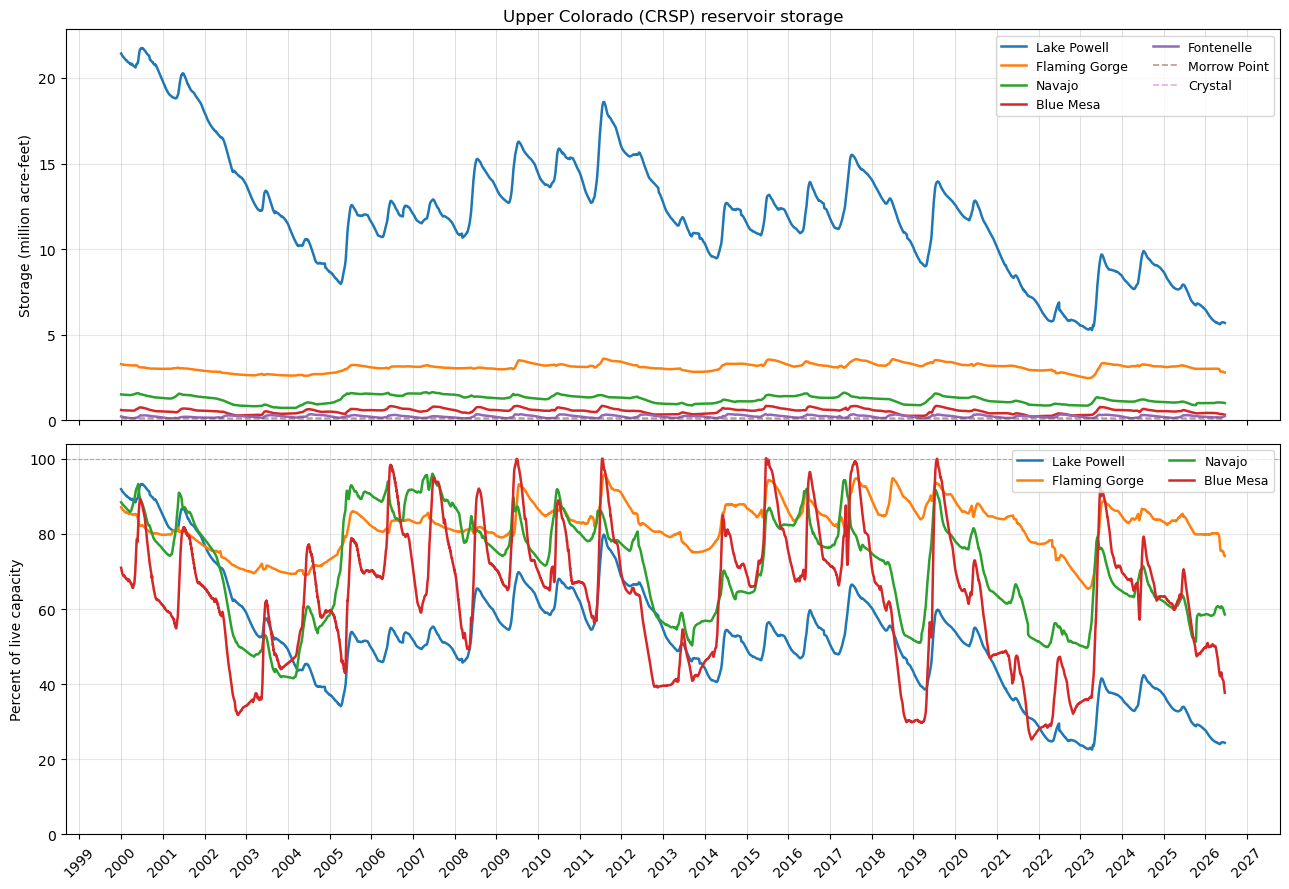

In [22]:
# Re-regulation pools (run near-full year-round) are kept in the absolute-storage panel for
# completeness but dropped from percent-full, where they add clutter without a drought signal.
REREG = {"Morrow Point", "Crystal"}
PCT_OMIT = REREG | {"Fontenelle"}
storage_cols = list(storage.columns)
pct_cols = [c for c in percent_full.columns if c not in PCT_OMIT]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Year boundary lines (Jan 1 each year), labels only every few years to avoid crowding.
for ax in (ax1, ax2):
    ax.tick_params(axis="x", rotation=45)
    ax.xaxis.set_major_locator(mdates.YearLocator())          # a tick at every Jan 1
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, which="major", axis="x", color="gray", lw=0.6, alpha=0.35)

# --- absolute storage (million af): all reservoirs; re-reg pools dashed/faded ---
# Note how Lake Powell alone dwarfs every other CRSP reservoir combined.
for col in storage_cols:
    style = dict(lw=1.2, ls="--", alpha=0.6) if col in REREG else dict(lw=1.8)
    ax1.plot(storage.index, storage[col] / 1e6, label=col, **style)
ax1.set_ylim(bottom=0)    
ax1.set_ylabel("Storage (million acre-feet)")
ax1.set_title("Upper Colorado (CRSP) reservoir storage")
ax1.legend(loc="upper right", ncol=2, fontsize=9)
ax1.grid(True, alpha=0.3)

# --- percent of live capacity: storage reservoirs only ---
for col in pct_cols:
    ax2.plot(percent_full.index, percent_full[col], lw=1.8, label=col)
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Percent of live capacity")
ax2.set_xlabel("")
ax2.axhline(100, color="gray", lw=0.8, ls="--", alpha=0.6)
ax2.legend(loc="upper right", ncol=2, fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# --- save to figures/ as both pdf (vector) and png (raster) ---
figdir = Path("figures")
figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "crsp_storage.pdf", bbox_inches="tight")
fig.savefig(figdir / "crsp_storage.png", dpi=150, bbox_inches="tight")
print(f"saved {figdir/'crsp_storage.pdf'} and {figdir/'crsp_storage.png'}")

plt.show()
